# Model Comparison

This notebook compares the non-keyboard agents used in `game_render.py` over `num_run` game sessions per model.

It reports average score, ticks survived, and waves reached, then visualizes the per-run distributions.

Note: score is cumulative reward from the environment, so a model can survive longer but still score lower if its actions trigger fewer positive rewards or more penalties.

In [9]:
from collections import OrderedDict
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agents import (
    PlayerV2,
    PlayerQ,
    ReinforceAgentV2,
    ACAgent3,
    TrainerAC3,
    RandomAgent,
    DoNothingAgent,
    HeuristicAgent,
)
import agents.actor_critic_agent_legacy as actor_critic_agent_legacy
import agents.actor_critic_agent_legacy_survival_kill_noclip as actor_critic_agent_legacy_survival_kill_noclip
from agents import actor_critic_agent_v3_survival_kill as actor_critic_agent_v3_survival_kill
import agents.heuristic_agent as heuristic_agent_module
from pvz import config
import torch

importlib.reload(actor_critic_agent_legacy)
importlib.reload(heuristic_agent_module)
HeuristicAgent = heuristic_agent_module.HeuristicAgent

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [10]:
num_run = 100

LEGACY_DDQN_MODEL = "agents/agent_zoo/dfq5_epsexp"
DDQN_RENDER_MODEL = "agents/agent_zoo/ddqn_new"
DDQN_NEW_MODEL = "agents/agent_zoo/ddqn_tfx"
REINFORCE_MODEL = "agents/agent_zoo/dfp5"
AC_POLICY_MODEL_0 = "ac_v3_survival_kill_compare_v1_policy.pt"
AC_VALUE_MODEL_0 = "ac_v3_survival_kill_compare_v1_value.pt"
# AC_POLICY_MODEL_0 = "agents/ac_legacy_compare_v1_policy.pt"
# AC_VALUE_MODEL_0 = "agents/ac_legacy_compare_v1_value.pt"
AC_POLICY_MODEL_2 = "agents/agent_zoo/actor-critic/ac_t_v2_policy.pt"
AC_VALUE_MODEL_2 = "agents/agent_zoo/actor-critic/ac_t_v2_value.pt"
# AC_POLICY_MODEL_2 = "agents/agent_zoo/ac_t_v5_value/ac_t_v5_policy.pt"
# AC_VALUE_MODEL_2 = "agents/agent_zoo/ac_t_v5_value/ac_t_v5_value.pt"

In [11]:
def scene_stats(env):
    base_env = getattr(env, "env", env)
    base_env = getattr(base_env, "unwrapped", base_env)
    scene = getattr(base_env, "_scene", None)
    if scene is None:
        return 0, 0

    chrono = getattr(scene, "_chrono", 0)
    wave = getattr(getattr(scene, "_zombie_spawner", None), "_wave_index", 0)
    return chrono, wave


def run_one_session(env, agent):
    summary = env.play(agent)
    try:
        score = float(np.sum(summary["raw_rewards"]))
    except KeyError:
        score = float(np.sum(summary["rewards"]))
    chrono, wave = scene_stats(env)
    ticks_survived = int(min(chrono, config.MAX_SECONDS))
    return {
        "score": score,
        "ticks_survived": ticks_survived,
        "waves": int(wave),
    }


def run_agent(label, env, agent, runs=num_run):
    rows = []
    for run_index in range(1, runs + 1):
        metrics = run_one_session(env, agent)
        metrics["model"] = label
        metrics["run"] = run_index
        rows.append(metrics)
    return pd.DataFrame(rows)


agent_specs = []

In [ ]:



missing_models = []
agent_specs = []


def add_spec(model, make_env, make_agent, load=None, checkpoint_paths=None):
    if checkpoint_paths is not None:
        if isinstance(checkpoint_paths, str):
            paths = [checkpoint_paths]
        else:
            paths = list(checkpoint_paths)
        if not all(Path(path).exists() for path in paths):
            missing_models.append(model)
            return
    agent_specs.append({
        "model": model,
        "make_env": make_env,
        "make_agent": make_agent,
        "load": load or (lambda agent: agent),
    })

# Legacy spec kept commented out as reference
# add_spec(
#     "Legacy Actor-Critic",
#     make_env=lambda: actor_critic_agent_legacy_survival_kill_noclip.TrainerAC3(render=False, max_frames=config.MAX_SECONDS),
#     make_agent=lambda env: actor_critic_agent_legacy_survival_kill_noclip.ACAgent3(
#         input_size=env.num_observations(),
#         possible_actions=env.get_actions(),
#     ),
#     load=lambda agent: agent.load(AC_POLICY_MODEL_0, AC_VALUE_MODEL_0),
#     checkpoint_paths=[AC_POLICY_MODEL_0, AC_VALUE_MODEL_0],
# )

add_spec(
    "Simple Reward",
    make_env=lambda: actor_critic_agent_v3_survival_kill.TrainerAC3(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: actor_critic_agent_v3_survival_kill.ACAgent3(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(AC_POLICY_MODEL_0, AC_VALUE_MODEL_0),
    checkpoint_paths=[AC_POLICY_MODEL_0, AC_VALUE_MODEL_0],
)

# IMPORTANT: AC_POLICY_MODEL_2 is a v3-style pretrained model and MUST be run
# with the v3 Trainer/Agent (same observation transform). Restoring that mapping.
add_spec(
    "Interim Reward",
    make_env=lambda: TrainerAC3(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: ACAgent3(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(AC_POLICY_MODEL_2, AC_VALUE_MODEL_2),
    checkpoint_paths=[AC_POLICY_MODEL_2, AC_VALUE_MODEL_2],
)

if missing_models:
    print("Skipped missing checkpoints:", ", ".join(missing_models))

results = []

for spec in agent_specs:
    env = spec["make_env"]()
    agent = spec["make_agent"](env)
    spec["load"](agent)
    print(f"Running agent: {spec['model']}...")
    results.append(run_agent(spec["model"], env, agent, runs=num_run))

results_df = pd.concat(results, ignore_index=True)
summary_df = (
    results_df.groupby("model", as_index=False)
    .agg(
        score_mean=("score", "mean"),
        score_std=("score", "std"),
        ticks_survived_mean=("ticks_survived", "mean"),
        ticks_survived_std=("ticks_survived", "std"),
        waves_mean=("waves", "mean"),
        waves_std=("waves", "std"),
    )
    .fillna(0.0)
)

model_order = [spec["model"] for spec in agent_specs]
results_df["model"] = pd.Categorical(results_df["model"], categories=model_order, ordered=True)
summary_df["model"] = pd.Categorical(summary_df["model"], categories=model_order, ordered=True)
summary_df = summary_df.sort_values("model").reset_index(drop=True)

results_df

Running agent: Simple Reward...
Running agent: Interim Reward...


,score,ticks_survived,waves,model,run
0,4122.0,214,7,Simple Reward,1
1,2687.0,159,6,Simple Reward,2
2,1780.0,118,5,Simple Reward,3
3,4851.0,169,7,Simple Reward,4
4,3318.0,172,6,Simple Reward,5
...,...,...,...,...,...
195,60411.0,1283,31,Interim Reward,96
196,4910.0,223,7,Interim Reward,97
197,52501.0,1204,30,Interim Reward,98
198,2070.0,129,4,Interim Reward,99


,model,score_mean,score_std,ticks_survived_mean,ticks_survived_std,waves_mean,waves_std
0,Simple Reward,5991.37,4125.602390,246.59,112.441778,8.03,2.872563
1,Interim Reward,20653.58,17369.187038,554.07,355.551904,15.46,8.421257


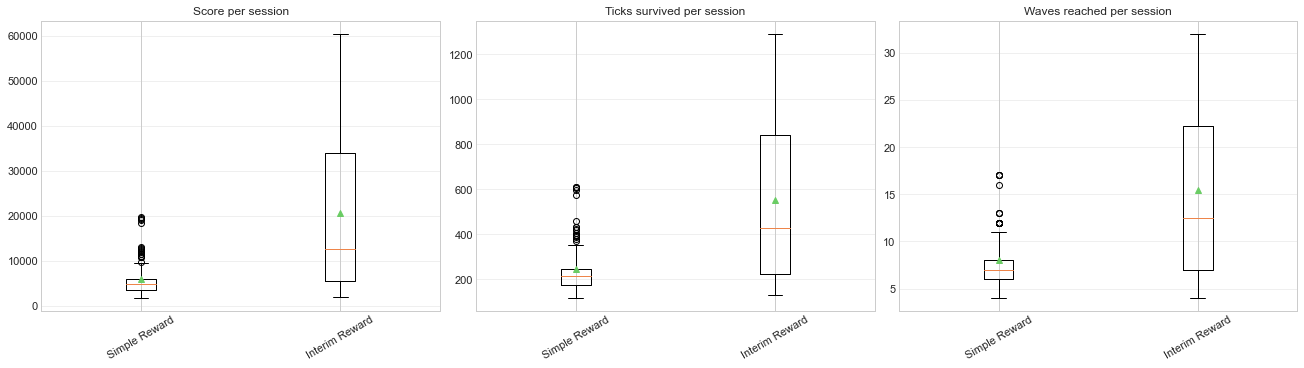

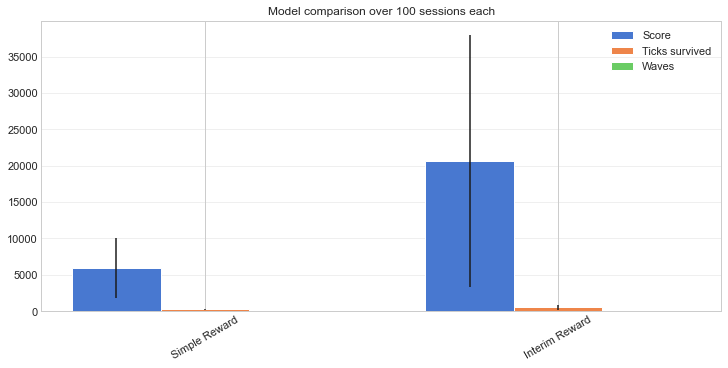

In [13]:
display(summary_df)
# Optional reference-line configuration (set numeric thresholds to draw).
# If the metric is plotted on the y-axis (violin/box/bar grouped), the reference is horizontal (axhline).
# If the metric is plotted on the x-axis (kde with x=metric), the reference is vertical (axvline).
vline_values = {"score": None, "ticks_survived": None, "waves": None}  # numeric thresholds
vline_labels = {"score": None, "ticks_survived": "human test", "waves": None}  # optional labels
bar_hline_value = None  # horizontal line across grouped bar chart (y coordinate).
bar_hline_label = "human test"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
metrics = [
    ("score", "Score per session"),
    ("ticks_survived", "Ticks survived per session"),
    ("waves", "Waves reached per session"),
]

for ax, (metric, title) in zip(axes, metrics):
    series = [results_df.loc[results_df["model"] == model, metric].to_numpy() for model in model_order]
    ax.boxplot(series, labels=model_order, showmeans=True)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    # Draw optional reference line for the metric. For boxplots the metric is on the y-axis, so draw horizontal.
    v = vline_values.get(metric)
    lbl = vline_labels.get(metric)
    if v is not None:
        ax.axhline(v, color='r', linestyle="--", linewidth=1.5)
        if lbl:
            ax.text(ax.get_xlim()[1], v, lbl, va='center', ha='right', color='r', fontsize=9, backgroundcolor='white')

plt.show()

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bar_width = 0.25
x = np.arange(len(summary_df))
ax.bar(x - bar_width, summary_df["score_mean"], bar_width, yerr=summary_df["score_std"], label="Score")
ax.bar(x, summary_df["ticks_survived_mean"], bar_width, yerr=summary_df["ticks_survived_std"], label="Ticks survived")
ax.bar(x + bar_width, summary_df["waves_mean"], bar_width, yerr=summary_df["waves_std"], label="Waves")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["model"], rotation=30)
ax.set_title(f"Model comparison over {num_run} sessions each")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
# Optional horizontal line over grouped bar chart (y coordinate)
if bar_hline_value is not None:
    ax.axhline(bar_hline_value, color='r', linestyle="--", linewidth=1.5)
    if bar_hline_label:
        ax.text(ax.get_xlim()[1], bar_hline_value, bar_hline_label, va='center', ha='right', color='r', fontsize=9, backgroundcolor='white')
plt.show()

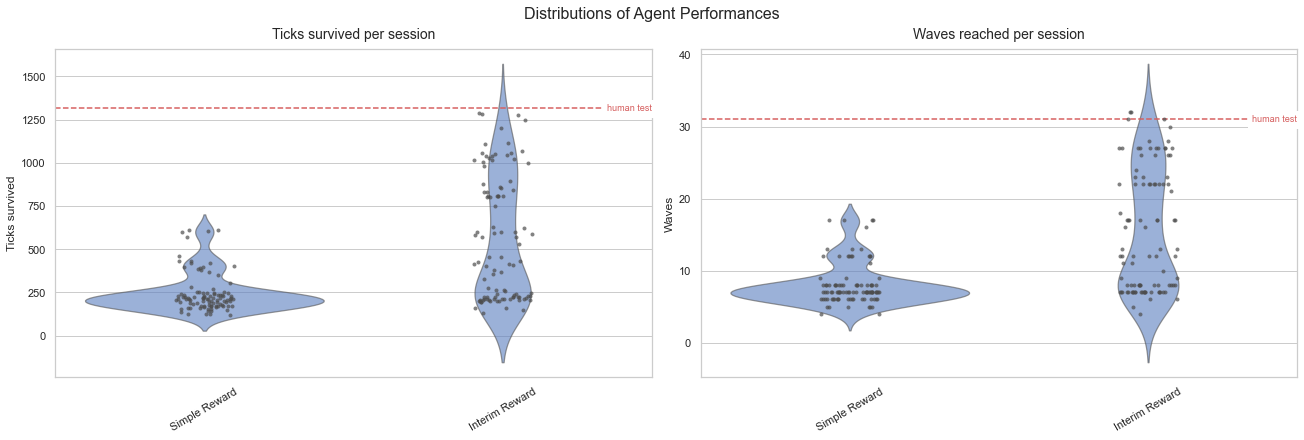

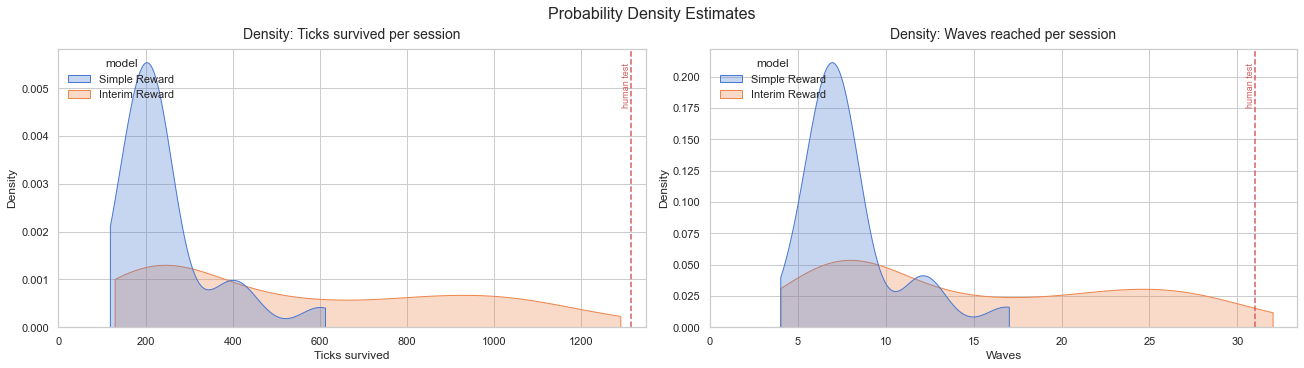

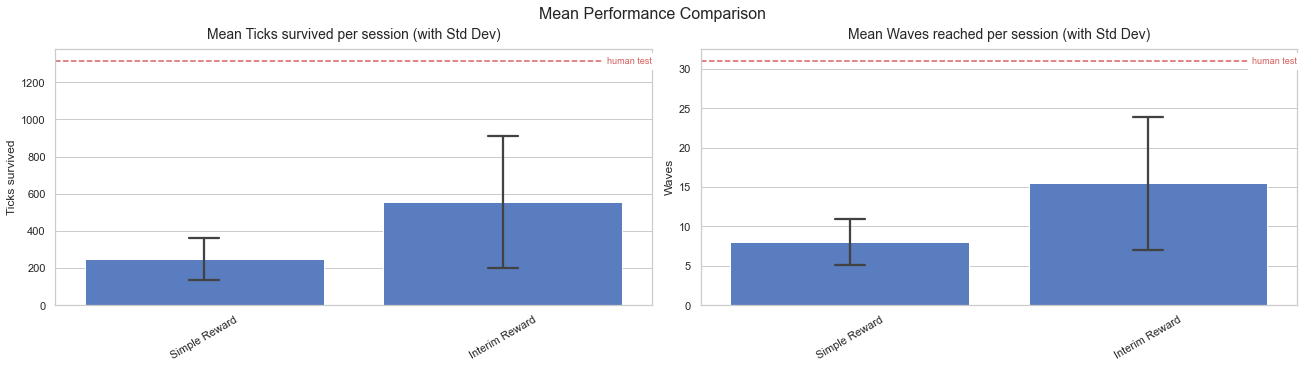

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn theme for better aesthetics
sns.set_theme(style="whitegrid", palette="muted")

metrics = [
    ("ticks_survived", "Ticks survived per session"),
    ("waves", "Waves reached per session"),
]

# Optional reference-line positions for continuous metric plots (set to None to disable)
# Use horizontal lines when metric is on the y-axis (violin/box/bar); vertical when metric is on the x-axis (kde).
vline_values = {"score": None, "ticks_survived": 1315, "waves": 31}
vline_labels = {"score": None, "ticks_survived": "human test", "waves": "human test"}

# 1. Violin plots with strip plots for data distribution
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 6), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.violinplot(data=results_df, x="model", y=metric, ax=ax, inner=None, alpha=0.6, order=model_order)
    sns.stripplot(data=results_df, x="model", y=metric, ax=ax, size=4, color=".3", jitter=True, order=model_order, alpha=0.7)
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(metric.capitalize().replace("_", " "))
    ax.tick_params(axis="x", rotation=30)
    # Draw horizontal reference line when metric is on the y-axis (if provided)
    v = vline_values.get(metric)
    lbl = vline_labels.get(metric)
    if v is not None:
        ax.axhline(v, color='r', linestyle="--", linewidth=1.5)
        if lbl:
            ax.text(ax.get_xlim()[1], v, lbl, va='center', ha='right', color='r', fontsize=9, backgroundcolor='white')
plt.suptitle("Distributions of Agent Performances", fontsize=16)
plt.show()

# 2. KDE Plots to show probability density
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.kdeplot(data=results_df, x=metric, hue="model", ax=ax, fill=True, common_norm=False, alpha=0.3, hue_order=model_order, cut=0, clip=(0, None))
    ax.set_title(f"Density: {title}", fontsize=14, pad=10)
    ax.set_xlabel(metric.capitalize().replace("_", " "))
    ax.set_xlim(left=0)

    # Draw optional vertical line at the configured x position for this metric (kde x=metric)
    v = vline_values.get(metric)
    lbl = vline_labels.get(metric)
    if v is not None:
        ax.axvline(v, color='r', linestyle="--", linewidth=1.5)
        if lbl:
            ax.text(v, ax.get_ylim()[1] * 0.95, lbl, rotation=90, va='top', ha='right', color='r', fontsize=9)
plt.suptitle("Probability Density Estimates", fontsize=16)
plt.show()

# 3. Bar charts for Mean Performance with Error Bars
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(data=results_df, x="model", y=metric, ax=ax, errorbar="sd", capsize=.1, order=model_order)
    ax.set_title(f"Mean {title} (with Std Dev)", fontsize=14, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(metric.capitalize().replace("_", " "))
    ax.tick_params(axis="x", rotation=30)
    # If a vline is configured for this metric and the plot has a numeric x-axis (e.g., aggregated values), draw it
    v = vline_values.get(metric)
    lbl = vline_labels.get(metric)
    if v is not None:
        try:
            ax.axhline(v, color='r', linestyle="--", linewidth=1.5)
            if lbl:
                ax.text(ax.get_xlim()[1], v, lbl, va='center', ha='right', color='r', fontsize=9, backgroundcolor='white')
        except Exception:
            pass
plt.suptitle("Mean Performance Comparison", fontsize=16)
plt.show()
